<a href="https://colab.research.google.com/github/VictorHugoDD/Analise-de-Vendas-Estaduais/blob/main/AnaliseVendasEstaduais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_original = pd.read_csv("dados_vendas_pe_ce_ba.csv", encoding="ISO-8859-1") #Fazendo os dados do excel serem lidos

**Conhecendo a base de dados**

In [ ]:
df_original.head()

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
0,1,BA,Salvador,Alimentos,4,754.47
1,2,PE,Recife,Roupas,9,147.37
2,3,PE,Petrolina,EletrÃ´nicos,2,80.19
3,4,PE,Recife,Roupas,9,621.92
4,5,PE,Petrolina,Roupas,7,716.26


In [ ]:
df_original.shape

(30, 6)

In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           30 non-null     int64  
 1   Estado       30 non-null     object 
 2   Cidade       30 non-null     object 
 3   Categoria    30 non-null     object 
 4   Quantidade   30 non-null     int64  
 5   Valor_Venda  30 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 1.5+ KB


**Qualidade dos dados**

In [ ]:
df_original.isnull().sum()

,0
ID,0
Estado,0
Cidade,0
Categoria,0
Quantidade,0
Valor_Venda,0


In [ ]:
df_original.duplicated().sum()

np.int64(0)

**Estatísticas descritivas**

In [ ]:
print(f"Media de Vendas : {df_original['Valor_Venda'].mean()}")
print(f"Maior valor da Venda: {df_original['Valor_Venda'].max()}")
print(f"Menor valor da Venda: {df_original['Valor_Venda'].min()}")
print(f"Media de Quantidade de Vendas : {df_original['Quantidade'].mean()}")


Media de Vendas : 496.5096666666667
Maior valor da Venda: 985.96
Menor valor da Venda: 80.19
Media de Quantidade de Vendas : 5.4


**Análise por estado**


*   Separar em  3 dataFrames:

1.   DataFrame do CE
2.   DataFrame do PE
3.   DataFrame do BA

Faremos a analise de cada um agora.


In [ ]:
#FUNÇOES PARA A ANALISE
def filtrarEstado(df_original,estado):
  df = df_original[df_original['Estado']==estado].copy()
  return df

def analiseEstado(df):
  print(f"\n      Analise {df['Estado'].iloc[0]}\n")
  print(f"Media de Vendas : {df['Valor_Venda'].mean():.2f}")
  print(f"Maior valor da Venda: {df['Valor_Venda'].max():.2f}")
  print(f"Menor valor da Venda: {df['Valor_Venda'].min():.2f}")
  print(f"Media de Quantidade de Vendas : {df['Quantidade'].mean():.2f}")
  print(f"Soma total do valor das vendas : {df['Valor_Venda'].sum():.2f}")
  print(f"Total de Quantidade de vendas : {len(df)}")
  print(f"Total de Produtos vendidos : {df['Quantidade'].sum()}")


In [ ]:
#CEARA
df_CE = filtrarEstado(df_original,'CE')
df_CE.head(df_CE.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
8,9,CE,Juazeiro do Norte,Roupas,1,301.29
11,12,CE,Sobral,Alimentos,1,719.34
17,18,CE,Sobral,Roupas,6,579.10
19,20,CE,Fortaleza,Alimentos,10,917.48
23,24,CE,Sobral,EletrÃ´nicos,3,393.90
29,30,CE,Sobral,EletrÃ´nicos,7,155.97


In [ ]:
#PERNAMBUCO
df_PE = df_original[df_original['Estado']=='PE'].copy()
df_PE.head(df_PE.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
1,2,PE,Recife,Roupas,9,147.37
2,3,PE,Petrolina,EletrÃ´nicos,2,80.19
3,4,PE,Recife,Roupas,9,621.92
4,5,PE,Petrolina,Roupas,7,716.26
5,6,PE,Caruaru,Roupas,1,314.28
6,7,PE,Petrolina,EletrÃ´nicos,3,373.24
7,8,PE,Caruaru,Alimentos,2,138.11
10,11,PE,Petrolina,EletrÃ´nicos,10,837.93
13,14,PE,Caruaru,EletrÃ´nicos,6,480.74
14,15,PE,Caruaru,EletrÃ´nicos,5,249.03


In [ ]:
#BAHIA
df_BA = filtrarEstado(df_original,'BA')
df_BA.head(df_BA.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
0,1,BA,Salvador,Alimentos,4,754.47
9,10,BA,Feira de Santana,Roupas,7,168.58
12,13,BA,Salvador,EletrÃ´nicos,4,985.96
15,16,BA,VitÃ³ria da Conquista,Roupas,3,117.83
16,17,BA,VitÃ³ria da Conquista,Alimentos,7,205.23
20,21,BA,Feira de Santana,Alimentos,7,672.67
21,22,BA,Feira de Santana,Alimentos,4,301.64
22,23,BA,VitÃ³ria da Conquista,Roupas,10,299.60
24,25,BA,Feira de Santana,Alimentos,2,767.99
26,27,BA,Salvador,EletrÃ´nicos,8,412.54


In [ ]:
analiseEstado(df_CE)
analiseEstado(df_PE)
analiseEstado(df_BA)


      Analise CE

Media de Vendas : 511.18
Maior valor da Venda: 917.48
Menor valor da Venda: 155.97
Media de Quantidade de Vendas : 4.67
Soma total do valor das vendas : 3067.08
Total de Quantidade de vendas : 6
Total de Produtos vendidos : 28

      Analise PE

Media de Vendas : 464.69
Maior valor da Venda: 837.93
Menor valor da Venda: 80.19
Media de Quantidade de Vendas : 5.67
Soma total do valor das vendas : 5576.34
Total de Quantidade de vendas : 12
Total de Produtos vendidos : 68

      Analise BA

Media de Vendas : 520.99
Maior valor da Venda: 985.96
Menor valor da Venda: 117.83
Media de Quantidade de Vendas : 5.50
Soma total do valor das vendas : 6251.87
Total de Quantidade de vendas : 12
Total de Produtos vendidos : 66


Responda às seguintes perguntas:

*   Qual estado realizou o maior número de vendas? **Pernambuco e Bahia**
*   Qual estado obteve o maior faturamento? **Bahia com o valor total 6251.87**.
*   Qual estado apresentou a maior quantidade total de produtos vendidos?
**Pernambuco com 68 vendas**.



<Axes: xlabel='Estado'>

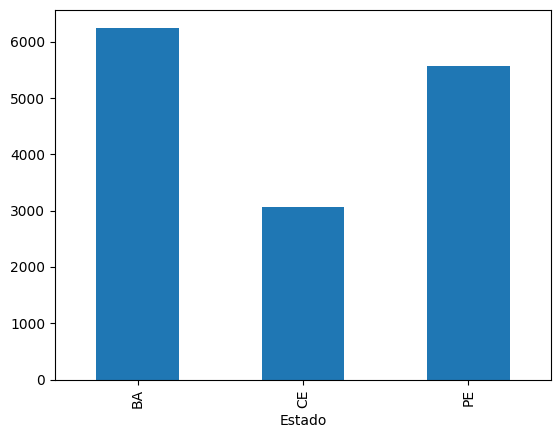

In [ ]:
df_original.groupby('Estado')['Valor_Venda'].sum().plot(kind='bar')



---


**Analise por Categoria**

In [ ]:
#FUNÇOES PARA A ANALISE
def filtrarCategoria(df_original,categoria):
  df = df_original[df_original['Categoria']==categoria].copy()
  return df

def analiseCategoria(df):
  print(f"\n      Analise {df['Categoria'].iloc[0]}\n")
  print(f"Media de Quantidade de Vendas : {df['Quantidade'].mean():.2f}")
  print(f"Soma total do valor das vendas : {df['Valor_Venda'].sum():.2f}")
  print(f"Total de Quantidade de vendas : {len(df)}")
  print(f"Total de Produtos vendidos : {df['Quantidade'].sum()}")


In [ ]:
#ROUPAS
df_Roupas = filtrarCategoria(df_original,'Roupas')
df_Roupas.head(df_Roupas.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
1,2,PE,Recife,Roupas,9,147.37
3,4,PE,Recife,Roupas,9,621.92
4,5,PE,Petrolina,Roupas,7,716.26
5,6,PE,Caruaru,Roupas,1,314.28
8,9,CE,Juazeiro do Norte,Roupas,1,301.29
9,10,BA,Feira de Santana,Roupas,7,168.58
15,16,BA,VitÃ³ria da Conquista,Roupas,3,117.83
17,18,CE,Sobral,Roupas,6,579.10
22,23,BA,VitÃ³ria da Conquista,Roupas,10,299.60
27,28,BA,Feira de Santana,Roupas,1,867.74


In [ ]:
#ALIMENTOS
df_Alimentos = filtrarCategoria(df_original,'Alimentos')
df_Alimentos.head(df_Alimentos.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
0,1,BA,Salvador,Alimentos,4,754.47
7,8,PE,Caruaru,Alimentos,2,138.11
11,12,CE,Sobral,Alimentos,1,719.34
16,17,BA,VitÃ³ria da Conquista,Alimentos,7,205.23
18,19,PE,Recife,Alimentos,7,814.79
19,20,CE,Fortaleza,Alimentos,10,917.48
20,21,BA,Feira de Santana,Alimentos,7,672.67
21,22,BA,Feira de Santana,Alimentos,4,301.64
24,25,BA,Feira de Santana,Alimentos,2,767.99
25,26,PE,Petrolina,Alimentos,7,802.48


In [ ]:
#ELETRONICOS
df_Eletronicos = filtrarCategoria(df_original,'EletrÃ´nicos')
df_Eletronicos.head(df_Eletronicos.shape[0]) #Confirma que recebeu o dataframe filtrado

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
2,3,PE,Petrolina,EletrÃ´nicos,2,80.19
6,7,PE,Petrolina,EletrÃ´nicos,3,373.24
10,11,PE,Petrolina,EletrÃ´nicos,10,837.93
12,13,BA,Salvador,EletrÃ´nicos,4,985.96
13,14,PE,Caruaru,EletrÃ´nicos,6,480.74
14,15,PE,Caruaru,EletrÃ´nicos,5,249.03
23,24,CE,Sobral,EletrÃ´nicos,3,393.90
26,27,BA,Salvador,EletrÃ´nicos,8,412.54
29,30,CE,Sobral,EletrÃ´nicos,7,155.97


In [ ]:
analiseCategoria(df_Alimentos)
analiseCategoria(df_Roupas)
analiseCategoria(df_Eletronicos)


      Analise Alimentos

Media de Quantidade de Vendas : 5.45
Soma total do valor das vendas : 6791.82
Total de Quantidade de vendas : 11
Total de Produtos vendidos : 60

      Analise Roupas

Media de Quantidade de Vendas : 5.40
Soma total do valor das vendas : 4133.97
Total de Quantidade de vendas : 10
Total de Produtos vendidos : 54

      Analise EletrÃ´nicos

Media de Quantidade de Vendas : 5.33
Soma total do valor das vendas : 3969.50
Total de Quantidade de vendas : 9
Total de Produtos vendidos : 48


---


*   Qual categoria possui mais vendas? **Alimentos**

*   Qual categoria gerou o maior faturamento? **Alimentos**

*   Qual categoria vendeu mais unidades? **Alimentos**






<Axes: ylabel='Valor_Venda'>

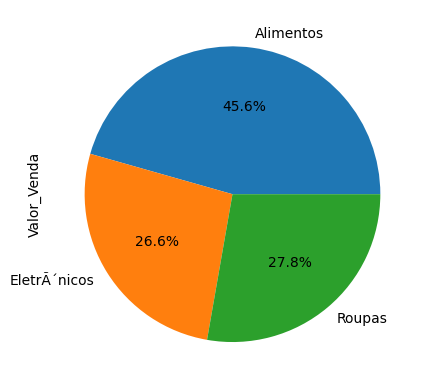

In [ ]:
df_original.groupby('Categoria')['Valor_Venda'].sum().plot.pie(autopct='%1.1f%%')


---
**Análise por cidade**



In [ ]:
#FUNÇOES PARA A ANALISE

def mostrarDadosCidade(df):
  print(f"\n      Analise {df['Cidade'].iloc[0]}\n")
  print(f"Media de Vendas : {df['Valor_Venda'].mean():.2f}")
  print(f"Maior valor da Venda: {df['Valor_Venda'].max():.2f}")
  print(f"Menor valor da Venda: {df['Valor_Venda'].min():.2f}")
  print(f"Media de Quantidade de Vendas : {df['Quantidade'].mean():.2f}")
  print(f"Soma total do valor das vendas : {df['Valor_Venda'].sum():.2f}")
  print(f"Total de Quantidade de vendas : {len(df)}")
  print(f"Total de Produtos vendidos : {df['Quantidade'].sum()}")

def filtrarCidade(df_original):
  dicionario_cidades={}
  for cidade in df_original['Cidade'].unique():
    # Guarda o DataFrame associado ao nome da cidade
    dicionario_cidades[cidade] = df_original[df_original['Cidade'] == cidade].copy()

  return dicionario_cidades

def analiseCidade(df):
  dic_cidades=filtrarCidade(df)

  for cidade, df in dic_cidades.items():
    mostrarDadosCidade(df)

  maior_faturamento={'cidade': None, 'valor': -float('inf')}
  maior_num_vendas={'cidade': None, 'quantidade': -float('inf')}
  mais_produtos={'cidade': None, 'quantidade': -float('inf')}

  for cidade,df in dic_cidades.items():
    faturamento = df['Valor_Venda'].sum()
    num_vendas = len(df)
    total_produtos = df['Quantidade'].sum()

    if faturamento > maior_faturamento['valor']:
      maior_faturamento['valor']=faturamento
      maior_faturamento['cidade']=cidade

    if num_vendas > maior_num_vendas['quantidade']:
      maior_num_vendas['quantidade']=num_vendas
      maior_num_vendas['cidade']=cidade

    if total_produtos > mais_produtos['quantidade']:
      mais_produtos['quantidade']=total_produtos
      mais_produtos['cidade']=cidade


  print(f"\n\n\nQual cidade apresentou o maior faturamento? : {maior_faturamento['cidade']} com {maior_faturamento['valor']} faturado.")
  print(f"Qual cidade realizou o maior número de vendas? : {maior_num_vendas['cidade']} com {maior_num_vendas['quantidade']} vendidos.")
  print(f"Qual cidade vendeu mais produtos? : {mais_produtos['cidade']} com {mais_produtos['quantidade']} produtos vendidos.")




In [ ]:
analiseCidade(df_original)


      Analise Salvador

Media de Vendas : 717.66
Maior valor da Venda: 985.96
Menor valor da Venda: 412.54
Media de Quantidade de Vendas : 5.33
Soma total do valor das vendas : 2152.97
Total de Quantidade de vendas : 3
Total de Produtos vendidos : 16

      Analise Recife

Media de Vendas : 528.03
Maior valor da Venda: 814.79
Menor valor da Venda: 147.37
Media de Quantidade de Vendas : 8.33
Soma total do valor das vendas : 1584.08
Total de Quantidade de vendas : 3
Total de Produtos vendidos : 25

      Analise Petrolina

Media de Vendas : 562.02
Maior valor da Venda: 837.93
Menor valor da Venda: 80.19
Media de Quantidade de Vendas : 5.80
Soma total do valor das vendas : 2810.10
Total de Quantidade de vendas : 5
Total de Produtos vendidos : 29

      Analise Caruaru

Media de Vendas : 295.54
Maior valor da Venda: 480.74
Menor valor da Venda: 138.11
Media de Quantidade de Vendas : 3.50
Soma total do valor das vendas : 1182.16
Total de Quantidade de vendas : 4
Total de Produtos vendidos 



---


* Qual cidade apresentou o maior faturamento? : **Petrolina com 2810.1 faturado.**
* Qual cidade realizou o maior número de vendas? : **Petrolina com 5 vendidos e Feira de Santana.**
* Qual cidade vendeu mais produtos? : **Petrolina com 29 produtos vendidos.**


<Axes: xlabel='Cidade'>

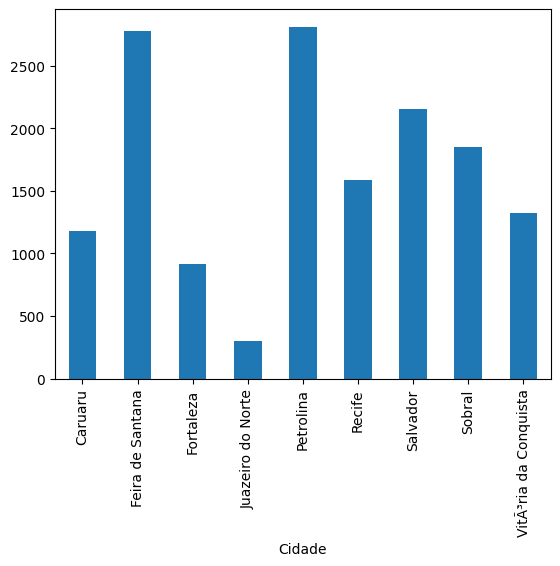

In [ ]:
df_original.groupby('Cidade')['Valor_Venda'].sum().plot(kind='bar')



---
**Distribuição dos valores de venda**


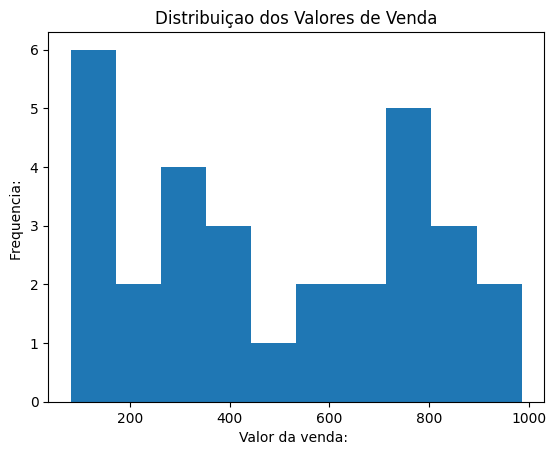

In [ ]:
plt.hist(df_original['Valor_Venda'])
plt.title('Distribuiçao dos Valores de Venda')
plt.xlabel("Valor da venda: ")
plt.ylabel("Frequencia: ")
plt.show()

Após o gráfico, explique:
* Existem muitas vendas pequenas?
* Existem muitas vendas altas?
* Os valores estão concentrados em alguma faixa?

Existem muitas vendas pequenas , enquanto de forma moderada existem vendas altas. Os valores se concentram em vendas pequenas, em segundo lugar se concentrar nos valores altos e por ultimo em vendas de medio valor.



---
**Identificação de valores extremos**


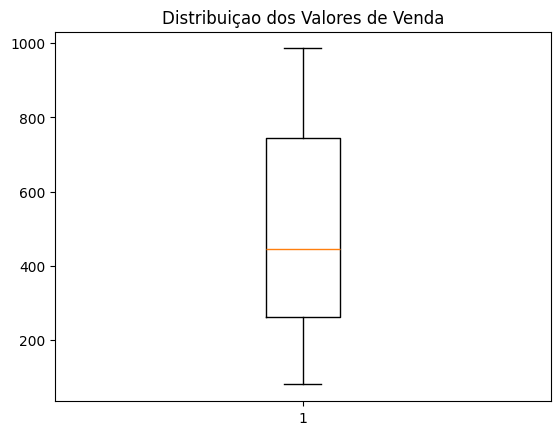

In [ ]:
plt.boxplot(df_original['Valor_Venda'])
plt.title('Distribuiçao dos Valores de Venda')
plt.show()

Percebe-se grande variação, principalmente em valores maiores. Vemos que a media esta em torno de valores menores.


Nao existe outliers,os outliers impacta na hr da interpretação de medidas de posiçao e de disperçao.


---
**Agrupamentos utilizando GroupBy**




In [ ]:
def faturamentoPorEstado(df):
  df_fat_est=df.groupby('Estado')['Valor_Venda'].sum().copy()
  print(f"\n\n{df_fat_est}")

def faturamentoPorCategoria(df):
  df_fat_cat=df.groupby('Categoria')['Valor_Venda'].sum().copy()
  print(f"\n\n{df_fat_cat}")

def quantidadePorCidade(df):
  df_fat_cid=df.groupby('Cidade')['Valor_Venda'].count().copy()
  print(f"\n\n{df_fat_cid}")

def mediaVendasPorEstado(df):
  df_fat_est=df.groupby('Estado')['Valor_Venda'].mean().copy()
  print(f"\n\n{df_fat_est}")

def agrupamentos(df):
  faturamentoPorEstado(df)
  faturamentoPorCategoria(df)
  quantidadePorCidade(df)
  mediaVendasPorEstado(df)

agrupamentos(df_original)



Estado
BA    6251.87
CE    3067.08
PE    5576.34
Name: Valor_Venda, dtype: float64


Categoria
Alimentos       6791.82
EletrÃ´nicos    3969.50
Roupas          4133.97
Name: Valor_Venda, dtype: float64


Cidade
Caruaru                  4
Feira de Santana         5
Fortaleza                1
Juazeiro do Norte        1
Petrolina                5
Recife                   3
Salvador                 3
Sobral                   4
VitÃ³ria da Conquista    4
Name: Valor_Venda, dtype: int64


Estado
BA    520.989167
CE    511.180000
PE    464.695000
Name: Valor_Venda, dtype: float64



---

**Interpretação Final**

A coleta de dados esta limpa e consistene, não ha nenhuma outliers ou valores nulos. Isso significa que todas as medidas calculadas estao corretas e precisas.

Por meio da análise de dados, podemos observar que o estado com melhor desempenho foi a **Bahia**, pois é o estado que teve a maior renda de vendas ***(R\$ 6.251,87)***, mesmo sem ser o que mais vendeu produtos. **Pernambuco** e **Bahia** empataram na quantidade de vendas, mas **Pernambuco** vendeu mais produtos que a **Bahia** (foram 68 produtos vendidos de **Pernambuco** contra 66 da **Bahia**). Porém, **Pernambuco** faturou menos que a **Bahia**. Já o **Ceará** foi o estado que teve menos vendas e produtos vendidos, com apenas 6 vendas e 28 produtos comercializados. Por isso, a **Bahia** é o estado com melhor desempenho, por conta da média de valores de vendas ser maior.

Analisando as categorias, a que gerou maior faturamento foi a de **Alimentos** ***(R\$ 6.791,82)*** Ela possui uma quantidade de vendas e de produtos vendidos um pouco maior do que as outras áreas para efeito de comparação, as quantidades de vendas e produtos de **Roupas** são, respectivamente, 10 e 54, e de **Eletrônicos** temos 9 e 48. Mesmo com essa proximidade física, a receita de **Alimentos** é muito superior à de **Roupas** ***(R\$ 4.133,97)*** e **Eletrônicos** ***(R\$ 3.969,50)***. Apesar de os números de vendas e produtos vendidos serem muito próximos entre os setores, o motivo de a categoria de **Alimentos** gerar tanto faturamento é que ela sozinha representa quase 46% do faturamento total do negócio,enquanto os outros produtos representa cerca de 27% cada, evidenciando que seus produtos possuem um valor médio de venda muito mais alto.

Percebe-se que ha uma demanda maior em vendas de valor pequeno ***(R\$ 80-400)***, e em segundo lugar vendas de valores altos ***(R\$ 700-990)*** e de menor demando vendas de valores medios ***(R\$ 400-600)***.

Pelos topicos citados, podemos sugerir entender o que podemos melhorar no Ceará, e aplicar estrategias para atrair e elevar o numero de vendas.








